# Propagation of DCM labels

This notebook calculates the propagation rate and performs simulations to predict how many cell divisions are trackable.

## Input

- Statistics of MeD-seq samples (MeD-seq.statistics.txt)
- Table with CellTrace intensities (hardcoded)

## Output

- Figure 1g: Scatter plot with DCM/CpG ratios and CellTrace intensity
- Figure 1h: Bar plot with propagation rate per replicate
- Figure S3d: Bar plot with propagation rate per chase interval
- Figure 1i. Barplot of detected genes per cell division
- Figure S3e. ROC curve

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
import math
from sklearn.metrics import roc_curve, auc

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
level_colors = ["#95c1b6", "#5f8386", "#264653"]  # colors for profile plots
n_bins = 50

timepoint_colors = ["#E27D68", "#eca997", "#ecc9c2"] 
celltrace_color = "#CC1421"

## MeD-seq and Celltrace input data

In [3]:
# Get correction factors
stats = pd.read_csv(f"../Input/MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)
stats = stats[(stats["Condition"] == "iPSC C4 -dox") | (stats["Experiment"] == "iPSC propagation")]

# The CellTrace intensities were measured using Flow Cytometry
stats["CellTrace"] = [35.1, 30.7, 28.3, 41633, 41633, 16856, 16269, 4860, 4472, 1666, 1738]
stats["Chase"] = ["neg"]*3 + ["0"]*2 + ["1"]*2 + ["2"]*2 + ["3"]*2
stats["Replicate"] = [np.nan]*3 + [1, 2]*4
stats["Replicate"] = stats["Replicate"].astype("Int64")
display(stats)

# An additional replicate per time point was measured using Flow cytometry, but not sequenced
replicate3 = pd.DataFrame.from_dict({"T0-3": [41633, 0, 3], "T24-3": [14191, 1, 3], "T48-3": [4033, 2, 3], "T72-3": [1515, 3, 3]},
                                     orient="index", columns=["CellTrace", "Chase", "Replicate"])
celltrace_stats = pd.concat([stats[["CellTrace", "Chase", "Replicate"]], replicate3])
display(celltrace_stats)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor,CellTrace,Chase,Replicate
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674,35.1,neg,<NA>
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592,30.7,neg,<NA>
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672,28.3,neg,<NA>
T0-1,iPSC propagation,iPSC 0h,iPSCs CellTrace 0h rep1,473045,146485,326560,0.473045,0.146485,0.326560,0.448570,0.002402,0.522520,41633.0,0,1
T0-2,iPSC propagation,iPSC 0h,iPSCs CellTrace 0h rep2,424895,115254,309641,0.424895,0.115254,0.309641,0.372218,0.001947,0.380456,41633.0,0,2
T24-1,iPSC propagation,iPSC 24h,iPSCs CellTrace 24h rep1,370062,63320,306742,0.370062,0.063320,0.306742,0.206428,0.001316,0.223933,16856.0,1,1
T24-2,iPSC propagation,iPSC 24h,iPSCs CellTrace 24h rep2,433831,80944,352887,0.433831,0.080944,0.352887,0.229377,0.001548,0.308717,16269.0,1,2
T48-1,iPSC propagation,iPSC 48h,iPSCs CellTrace 48h rep1,722456,81646,640810,0.722456,0.081646,0.640810,0.127411,0.000941,0.312619,4860.0,2,1
T48-2,iPSC propagation,iPSC 48h,iPSCs CellTrace 48h rep2,436528,44152,392376,0.436528,0.044152,0.392376,0.112525,0.000828,0.166142,4472.0,2,2
T72-1,iPSC propagation,iPSC 72h,iPSCs CellTrace 72h rep1,413751,29769,383982,0.413751,0.029769,0.383982,0.077527,0.000612,0.116472,1666.0,3,1


,CellTrace,Chase,Replicate
C4neg-1,35.1,neg,<NA>
C4neg-2,30.7,neg,<NA>
C4neg-3,28.3,neg,<NA>
T0-1,41633.0,0,1
T0-2,41633.0,0,2
T24-1,16856.0,1,1
T24-2,16269.0,1,2
T48-1,4860.0,2,1
T48-2,4472.0,2,2
T72-1,1666.0,3,1


## Figure 1g: Scatter plot with DCM/CpG ratios and CellTrace intensity

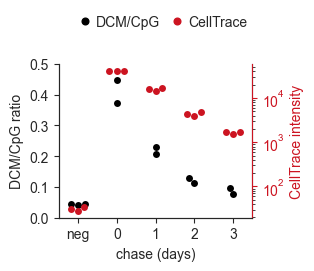

In [4]:
np.random.seed(124)

# Scatter plot
fig, ax1 = plt.subplots(figsize=(2.5, 2))

# DCM/CpG ratio
sns.swarmplot(data=stats, x="Chase", y="DCM/CpG ratio", s=5, color="black", order=["neg", 0, 1, 2, 3], ax=ax1)
ax1.set(ylim=(0, 0.5), xlabel="chase (days)", ylabel="DCM/CpG ratio")

# Celltrace intensity
ax2 = ax1.twinx()
sns.swarmplot(data=celltrace_stats, x="Chase", y="CellTrace", s=5, color=celltrace_color, order=["neg", 0, 1, 2, 3], ax=ax2)
ax2.set(ylabel="CellTrace intensity")
ax2.spines["right"].set_color(celltrace_color)
ax2.yaxis.label.set_color(celltrace_color)
ax2.tick_params(axis="y", colors=celltrace_color)
ax2.set_yscale("log") #, base=2)

# Legend
ratio_patch = matplotlib.lines.Line2D([], [], color="black", marker='o', linestyle='None', label="DCM/CpG")
celltrace_patch = matplotlib.lines.Line2D([], [], color=celltrace_color, marker='o', linestyle='None', label="CellTrace")
ax1.legend(handles=[ratio_patch, celltrace_patch], loc="upper left", bbox_to_anchor=(0, 1.4), frameon=False,
          markerscale=0.8, ncol=2, handletextpad=-0.2, columnspacing=0.2, labelspacing=0.05, fontsize=10)

sns.despine(top=True, bottom=False, left=False, right=False)
plt.savefig(f"{output_dir}/Figure1g.svg", format="svg")
plt.show()

## Calculate propagation rate

In [5]:
chase_intervals = ["0-1", "1-2", "2-3", "0-2", "1-3", "0-3"]
calculations = []

for replicate in [1,2]:
    for chase_interval in chase_intervals:
        start, end = chase_interval.split("-")
        start_sample = stats[(stats["Replicate"] == replicate) & (stats["Chase"] == start)]
        end_sample = stats[(stats["Replicate"] == replicate) & (stats["Chase"] == end)]

        ratio_lateearly =  end_sample["DCM/CpG ratio"].iloc[0] / start_sample["DCM/CpG ratio"].iloc[0]
        loss = 1 - ratio_lateearly
        no_divisions = math.log(end_sample["CellTrace"].iloc[0] / start_sample["CellTrace"].iloc[0], 0.5)
        propagation = ratio_lateearly ** (1 / no_divisions)
        
        calculations.append([replicate, chase_interval, ratio_lateearly, loss, no_divisions, propagation])

propagation_df = pd.DataFrame(calculations, columns=["Replicate", "Chase interval", "Ratio late/early", "Loss", "No divisions", "Propagation"])
display(propagation_df)

prop = propagation_df["Propagation"].mean(axis=0)
print(f"Propagation: {prop:.2f}")

,Replicate,Chase interval,Ratio late/early,Loss,No divisions,Propagation
0,1,0-1,0.460190,0.539810,1.304465,0.551580
1,1,1-2,0.617217,0.382783,1.794234,0.764192
2,1,2-3,0.608482,0.391518,1.544568,0.724962
3,1,0-2,0.284037,0.715963,3.098699,0.666186
4,1,1-3,0.375566,0.624434,3.338802,0.745787
5,1,0-3,0.172832,0.827168,4.643267,0.685189
6,2,0-1,0.616242,0.383758,1.355602,0.699687
7,2,1-2,0.490568,0.509432,1.863133,0.682321
8,2,2-3,0.864937,0.135063,1.363492,0.899050
9,2,0-2,0.302309,0.697691,3.218735,0.689582


Propagation: 0.72


## Figure 1h: Bar plot with propagation rate per replicate

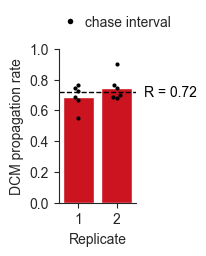

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(1, 2))
sns.barplot(data=propagation_df, x="Replicate", y="Propagation", errorbar=None, color=celltrace_color, ax=ax, saturation=1)
sns.swarmplot(data=propagation_df, x="Replicate", y="Propagation", color="black", s=3, ax=ax)

plt.ylim(0, 1)
plt.ylabel("DCM propagation rate")

# Line with mean value
ax.axhline(y=prop, color="black", linestyle="--", linewidth=1)
ax.text(x=1.7, y=prop, s=f"R = {prop:.2f}", color="black", fontsize=10, va="center")

# Legend
chase_dot = matplotlib.lines.Line2D([0], [0], marker="o", color="w", label="chase interval", markerfacecolor="black", markersize=5)
ax.legend(handles=[chase_dot], loc="upper left", bbox_to_anchor=(-0.2, 1.3), handletextpad=0.1, frameon=False)

sns.despine()
plt.savefig(f"{output_dir}/Figure1h.svg", format="svg")
plt.show()

In [7]:
rep1 = propagation_df.loc[propagation_df["Replicate"] == 1, "Propagation"]
rep2 = propagation_df.loc[propagation_df["Replicate"] == 2, "Propagation"]
stat, p_value = scipy.stats.mannwhitneyu(rep1, rep2, alternative="two-sided")
print(p_value)

0.30952380952380953


## Figure S3d: Bar plot with propagation rate per chase interval

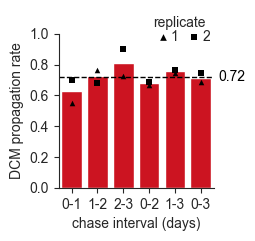

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
sns.barplot(data=propagation_df, x="Chase interval", y="Propagation", errorbar=None, color=celltrace_color, ax=ax, saturation=1)

replicate_markers = {1: "^", 2: "s"}
for rep, m in replicate_markers.items():
    sns.swarmplot(data=propagation_df[propagation_df["Replicate"] == rep], x="Chase interval", y="Propagation",
                  marker=m, color="black", size=4, ax=ax, label=rep)

# Axes
plt.ylim(0, 1)
plt.xlabel("chase interval (days)")
plt.ylabel("DCM propagation rate")

# Legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), title="replicate", loc="upper left", bbox_to_anchor=(0.5, 1.2), 
         frameon=False, fontsize=10, markerscale=1.2, ncol=2, handletextpad=-0.4, columnspacing=0.1, labelspacing=0.05)

# Line with mean value
ax.axhline(y=prop, color="black", linestyle="--", linewidth=1)
ax.text(x=5.7, y=prop, s=f"{prop:.2f}", color="black", fontsize=10, va="center")

sns.despine()
plt.savefig(f"{output_dir}/SupplementalFigure3d.svg", format="svg")
plt.show()

## In silico dilution of DCM labels in dox samples

In [14]:
counts = pd.read_csv(f"{input_dir}/GSE304236_DCMcounts.genes.txt", sep="\t", index_col=0, header=0)
counts = counts[counts["NrSites"] > 10]
counts = counts[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3"]]
display(counts)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3
GeneID,,,,,,
ENSG00000000003,1,2,4,90,65,66
ENSG00000000005,1,0,0,88,61,60
ENSG00000000419,16,14,6,485,306,267
ENSG00000000457,7,13,10,351,310,204
ENSG00000000460,43,40,42,1099,983,855
...,...,...,...,...,...,...
ENSG00000291296,7,4,2,63,28,21
ENSG00000291297,14,4,4,255,240,156
ENSG00000291299,198,107,136,1474,1019,820


In [15]:
# Define parameters
dox_samples = ["C4-1", "C4-2", "C4-3"]
num_divisions = 25

# Iterate through each division and add in silico diluted number of reads per gene
counts_diluted = counts.copy()
counts_diluted.index.name = None

# Add the non-diluted as seperate columns
for dox_sample in dox_samples:
    counts_diluted[f"{dox_sample}.div0"] = counts_diluted[dox_sample]

# Initialize the generator for random nummers
random_generator = np.random.default_rng()

# Apply binomial downsampling based on the previous state
for div in range(1, num_divisions + 1):
    for dox_sample in dox_samples:
        previous_counts = counts_diluted[f"{dox_sample}.div{div-1}"]
        counts_diluted[f"{dox_sample}.div{div}"] = random_generator.binomial(n=previous_counts, p=prop)
display(counts_diluted)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C4-1.div0,C4-2.div0,C4-3.div0,C4-1.div1,...,C4-3.div22,C4-1.div23,C4-2.div23,C4-3.div23,C4-1.div24,C4-2.div24,C4-3.div24,C4-1.div25,C4-2.div25,C4-3.div25
ENSG00000000003,1,2,4,90,65,66,90,65,66,70,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000005,1,0,0,88,61,60,88,61,60,64,...,0,1,0,0,1,0,0,1,0,0
ENSG00000000419,16,14,6,485,306,267,485,306,267,343,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000457,7,13,10,351,310,204,351,310,204,251,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000460,43,40,42,1099,983,855,1099,983,855,798,...,0,1,2,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291296,7,4,2,63,28,21,63,28,21,46,...,0,0,0,0,0,0,0,0,0,0
ENSG00000291297,14,4,4,255,240,156,255,240,156,190,...,0,0,1,0,0,0,0,0,0,0
ENSG00000291299,198,107,136,1474,1019,820,1474,1019,820,1072,...,2,0,0,2,0,0,2,0,0,1
ENSG00000291300,29,26,22,112,68,46,112,68,46,78,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# Check total library sizes
verification = []
original_reads = counts_diluted[f"C4-1"].sum()
for i in range(0, num_divisions+1):
    total_reads = counts_diluted[f"C4-1.div{i}"].sum()
    perc_total = total_reads / original_reads * 100
    verification.append({"Division": i, "Total": total_reads, "Percentage": perc_total})

display(pd.DataFrame(verification))

,Division,Total,Percentage
0,0,22914860,100.000000
1,1,16466492,71.859448
2,2,11828982,51.621446
3,3,8496227,37.077368
4,4,6104026,26.637850
5,5,4386835,19.144062
6,6,3149493,13.744326
7,7,2262083,9.871686
8,8,1625248,7.092550
9,9,1168409,5.098914


## DESeq2

In [17]:
%%R

# Set library path where packages are installed
.libPaths(c(file.path(Sys.getenv("CONDA_PREFIX"), "lib/R/library"), .libPaths()))
.libPaths()

# Load packages
packages <- c("DESeq2", "BiocParallel")
suppressMessages(invisible(lapply(packages, library, character.only = TRUE)))

# Set number of cores and memory to use
register(MulticoreParam(4))
options(future.globals.maxSize = 60000 * 1024^2, future.seed=42)
set.seed(42)

# List loaded packages
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 21.3

Matrix products: default
BLAS/LAPACK: /home/beatrice/miniconda3/envs/hDCM-TM/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=nl_NL.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=nl_NL.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=nl_NL.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.40.0         DESeq2_1.46.0              
 [3] SummarizedExperiment_1.36.0 Biobase_2.66.0             
 [5] MatrixGenerics_1.18.0       matrixStats_1.5.0          
 [7] GenomicRanges_1.58

In [18]:
%%R -i counts_diluted -i num_divisions -o DE_all

# Prepare controls
controls <- c("C4neg-1", "C4neg-2", "C4neg-3")
DE_all <- data.frame()

for (i in 0:num_divisions) {
    # Samples
    treated <- c(paste0("C4-1.div", i), paste0("C4-2.div", i), paste0("C4-3.div", i))
    current_samples <- c(controls, treated)
    
    # Create DESeq2 dataset
    sub_counts <- counts_diluted[, current_samples]
    sub_meta <- data.frame(row.names = current_samples,
                           Dox = factor(c(rep("NoDox", 3), rep("Dox", 3)), levels = c("NoDox", "Dox")))
    
    dds <- DESeqDataSetFromMatrix(countData = sub_counts, colData = sub_meta, design = ~Dox)
    dds <- DESeq(dds, fitType="local", parallel=TRUE, betaPrior=FALSE, quiet=TRUE)
    
    # Differential test
    res_diff <- results(dds, contrast=c("Dox", "Dox", "NoDox"), alpha=0.05)
    res_diff <- as.data.frame(lfcShrink(dds, contrast=c("Dox", "Dox", "NoDox"), res=res_diff, type="ashr", quiet=TRUE))
    
    # Add results to DE table
    res_diff$gene_id <- rownames(res_diff)
    res_diff$division <- i
    DE_all <- rbind(DE_all, res_diff)
}

In [19]:
display(DE_all)

,baseMean,log2FoldChange,lfcSE,pvalue,padj,gene_id,division
ENSG00000000003,13.443178,0.656544,0.517463,0.142319,0.203278,ENSG00000000003,0
ENSG00000000005,8.719786,1.875298,0.997553,0.003782,0.008756,ENSG00000000005,0
ENSG00000000419,64.220441,0.681029,0.285556,0.012696,0.025390,ENSG00000000419,0
ENSG00000000457,53.518550,0.655565,0.294177,0.019556,0.036985,ENSG00000000457,0
ENSG00000000460,199.109818,0.428391,0.163406,0.007847,0.016683,ENSG00000000460,0
...,...,...,...,...,...,...,...
ENSG0000029129625,0.203537,0.128683,0.939574,0.566159,NaN,ENSG00000291296,25
ENSG0000029129725,0.342502,0.086121,0.938640,0.701379,NaN,ENSG00000291297,25
ENSG0000029129925,8.841325,-0.729510,0.763708,0.116010,0.238714,ENSG00000291299,25
ENSG0000029130025,1.232946,-0.084484,0.825313,0.836163,NaN,ENSG00000291300,25


In [20]:
sig_counts = DE_all[(DE_all["padj"] < 0.05) & (DE_all["log2FoldChange"] > 1) & (DE_all["baseMean"] > 10)].groupby("division").size()
sig_summary = sig_counts.reset_index()
sig_summary.columns = ["Division", "Significant_Genes_Count"]
sig_summary["Percentage"] = sig_summary["Significant_Genes_Count"] / sig_summary.loc[0, "Significant_Genes_Count"]
display(sig_summary)

,Division,Significant_Genes_Count,Percentage
0,0,4367,1.000000
1,1,4161,0.952828
2,2,3899,0.892833
3,3,3612,0.827112
4,4,3347,0.766430
5,5,3060,0.700710
6,6,2728,0.624685
7,7,2420,0.554156
8,8,2090,0.478589
9,9,1807,0.413785


## Figure 1i. Barplot of detected genes per cell division

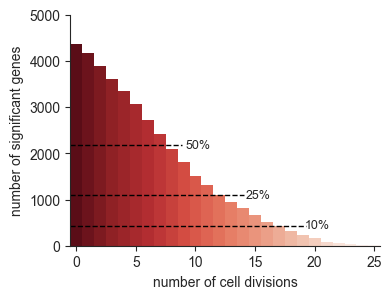

In [21]:
# Barplot
plt.figure(figsize=(4, 3))
sns.barplot(data=sig_summary, x="Division", y="Significant_Genes_Count", hue="Division", 
            width=1, palette="Reds_r", legend=False, linewidth=0)

# Axes
plt.xlabel("number of cell divisions")
plt.ylabel("number of significant genes")
plt.ylim(0, 5000)
plt.xticks([0,5,10,15,20,25])

# Percentages of total
total_genes = sig_summary.loc[sig_summary["Division"] == 0, "Significant_Genes_Count"].values[0]
for percentage, xpos in zip([10, 25, 50], [19, 14, 9]):
    yval = total_genes * percentage / 100
    plt.axhline(xmin=0, xmax=xpos/num_divisions, y=yval, color="black", linestyle="--", linewidth=1)
    plt.text(x=xpos+0.2, y=yval, s=f"{percentage}%", va="center", fontsize=9)

sns.despine()
plt.savefig(f"{output_dir}/Figure1i.svg", format="svg")
plt.show()

## Figure S3e. ROC curve

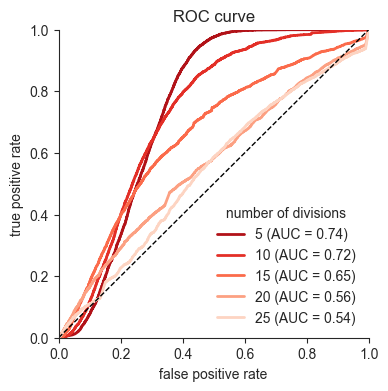

In [22]:
# True positives = significant genes in non-diluted samples
truth_df = DE_all[DE_all["division"] == 0].copy()
truth_df["is_true_de"] = ((truth_df["padj"] < 0.05) & (truth_df["log2FoldChange"] > 1)).astype(int)

# Plot
plt.figure(figsize=(4, 4))

divisions_to_plot = [5, 10, 15, 20, 25]
colors = sns.color_palette("Reds_r", len(divisions_to_plot))

for i, div in enumerate(divisions_to_plot):
    current_div = DE_all[DE_all["division"] == div].copy()
    merged = truth_df[["gene_id", "is_true_de"]].merge(current_div[["gene_id", "pvalue"]], on="gene_id")
    merged["pvalue"] = merged["pvalue"].fillna(1.0)
    
    # Predictor: 1 - pvalue (higher means more likely to be DE)
    fpr, tpr, _ = roc_curve(merged["is_true_de"], 1 - merged["pvalue"])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{div} (AUC = {roc_auc:.2f})")

# Axes
plt.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--") # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend(loc="lower right", title="number of divisions", frameon=False)

sns.despine()
plt.savefig(f"{output_dir}/SupplementalFigure3e.svg", format="svg")
plt.show()